In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [75]:
df = pd.read_csv("dinoDatasetCSV.csv")

## Cleaning Large Columns

In [55]:
## there's way too many. Let's consolidate
def recode_period(x):
    if not isinstance(x, str):
        return x
        
    x = x.lower()

    if 'cretaceous' in x:
        return 'Cretaceous'
    elif 'jurassic' in x:
        return 'Jurassic'
    elif 'triassic':
        return 'Triassic'
    else:
        'Other'

df['cleaned_geological_period'] = df['geological_period'].apply(recode_period)

In [58]:
## there's too many. Let's consolidate
def recode_locomotion(x):
    if not isinstance(x, str):
        return x
        
    x = x.lower()

    if 'unknown' in x or '?' in x or 'varies' in x:
        return 'Other'

    if 'aquatic' in x:
        return 'Aquatic'
    elif 'bipedal' in x and 'quadrupedal' in x:
        return 'Bipedal/Quadrupedal'    
    elif 'bipedal' in x:
        return 'Bipedal'
    else:
        return 'Quadrupedal'

df['cleaned_locomotion'] = df['locomotion'].apply(recode_locomotion)

In [61]:
## there's too many. Let's consolidate
def recode_diet(x):
    if not isinstance(x, str):
        return x
        
    x = x.lower()

    if 'unknown' in x or '?' in x:
        return 'Other'

    if 'carnivore' in x:
        return 'Carnivore'
    elif 'herbivore' in x:
        return 'Herbivore'    
    elif 'omnivore' in x:
        return 'Omnivore'
    else:
        return 'Insectivore'

df['cleaned_diet'] = df['diet'].apply(recode_diet)

In [64]:
## there's too many. Let's consolidate
def recode_intelligence_level(x):
    if not isinstance(x, str):
        return x
        
    x = x.lower()

    if 'unknown' in x or '?' in x:
        return 'Other'

    if 'small' in x or 'low' in x or 'tiny' in x:
        return 'Small'
    elif 'medium' in x:
        return 'Medium'    
    else:
        return 'Large'

df['cleaned_intelligence_level'] = df['intelligence_level'].apply(recode_intelligence_level)

In [67]:
def recode_first_discovered(x):
    if not isinstance(x, str):
        return x
        
    x = x.lower()

    if 'unknown' in x or '?' in x:
        return 'Other'

    if '18' in x :
        return '1800-1899'
    elif '19' in x:
        return '1900-1999'    
    else:
        return '>2000'

df['cleaned_first_discovered'] = df['first_discovered'].apply(recode_first_discovered)

In [69]:
fossil_location_vc = df["fossil_location"].value_counts()

rare_locations = fossil_location_vc[fossil_location_vc < 5].index

In [70]:
def recode_fossil_location(x):
    if not isinstance(x, str):
        return 'Other'
    
    if x in rare_locations:
        return 'Other'
    else:
        return x

df['cleaned_fossil_location'] = df['fossil_location'].apply(recode_fossil_location)

In [72]:
df.duplicated().sum()

np.int64(0)

## Data Analysis

In [73]:
df.describe(include = 'str')

,scientific_name,common_name,meaning,diet,locomotion,geological_period,lived_in,behavior_notes,first_discovered,fossil_location,notable_features,intelligence_level,source_link,cleaned_geological_period,cleaned_locomotion,cleaned_diet,cleaned_intelligence_level,cleaned_first_discovered,cleaned_fossil_location
count,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542,1542
unique,1538,1527,1338,11,16,73,133,599,171,351,744,14,1524,3,5,5,4,4,34
top,Kritosaurus,Kritosaurus,Different lizard,Herbivore,Bipedal,Late Cretaceous,North America,Theropod dinosaur,2019,China,Large sauropod,Medium,https://en.wikipedia.org/wiki/Kritosaurus,Cretaceous,Bipedal,Herbivore,Medium,>2000,Other
freq,3,3,20,971,913,659,253,265,100,238,86,777,3,1010,916,972,778,705,437


### outliers

In [80]:
## clipping outliers
def IQR(col):
    q1,q3 = np.percentile(col,[25,75])
    iqr = q3 - q1
    lw = q1 - 1.5 * iqr
    uw = q3 + 1.5 * iqr
    return lw,uw

for x in ['length_m', 'weight_kg', 'height_m']:
    lw,uw = IQR(df[x])
    df[x] = np.clip(df[x], lw, uw)

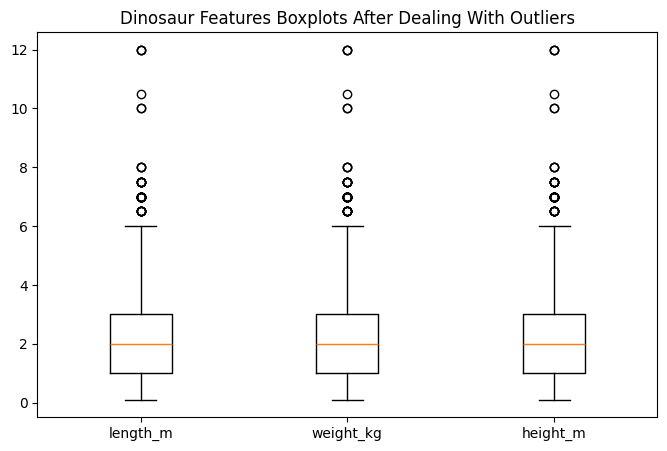

In [140]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [df[x].dropna() for col in ['length_m','weight_kg','height_m']],
    tick_labels=['length_m','weight_kg','height_m']
)

plt.title("Dinosaur Features Boxplots After Dealing With Outliers")
plt.show()

## Check + Replace nan

In [33]:
df.isnull()

,scientific_name,common_name,meaning,diet,length_m,weight_kg,height_m,locomotion,geological_period,lived_in,...,notable_features,intelligence_level,source_link,row_index,cleaned_geological_period,cleaned_locomotion,cleaned_diet,cleaned_intelligence_level,cleaned_first_discovered,cleaned_fossil_location
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1537,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1538,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1539,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1540,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [36]:
## Most of the dinosaurs that were missing height also missed weight and length. Dinosaurs with three unknowns were dropped

df_dropped_based_on_height = df.dropna(subset=['height_m'])

In [40]:
df_new = df_dropped_height_replaced_qs.dropna(subset=['length_m'])

In [43]:
df_new.loc[df_new["weight_kg"].isna(), "weight_kg"] = 300.0

In [45]:
## dropping dino name bc unnecessary in data

In [47]:
df_new = df_new.drop(columns=["notable_features", "scientific_name", "common_name", "meaning", "behavior_notes", "row_index", "source_link",
                             "intelligence_level", "lived_in", "geological_period", "locomotion", "diet", "first_discovered",
                             "fossil_location"])

# Data Preprocessing

## Label Encoding

In [53]:
df_new = pd.get_dummies(df_new, columns=["cleaned_locomotion", "cleaned_diet", "cleaned_intelligence_level",
                                        "cleaned_first_discovered", "cleaned_fossil_location"])

In [54]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_new["cleaned_geological_period"] = le.fit_transform(df_new["cleaned_geological_period"])

## Train/Test

In [90]:
from sklearn.model_selection import train_test_split

In [96]:
X = df_new.drop('cleaned_geological_period', axis = 1)
y = df_new['cleaned_geological_period']

print('Target variable distribution:')
print(y.value_counts().sort_index())
print(f'\nClass mapping: 0 = Cretaceous, 1 = Jurassic, 2 = Triassic\n')

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 42, stratify = y)

print(f'Training set size: {X_train.shape[0]} samples')
print(f'Test set size: {X_test.shape[0]} samples')
print(f'Number of features: {X_train.shape[1]}')

Target variable distribution:
cleaned_geological_period
0    988
1    439
2     76
Name: count, dtype: int64

Class mapping: 0 = Cretaceous, 1 = Jurassic, 2 = Triassic

Training set size: 1202 samples
Test set size: 301 samples
Number of features: 55


## Scaling

In [105]:
from sklearn.preprocessing import StandardScaler

## using this for logistic regression and KNN

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression

In [159]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix. f1_score

In [171]:
from sklearn.pipeline import make_pipeline

model_logreg = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

In [172]:
model_logreg = LogisticRegression(max_iter=5000, class_weight = 'balanced')
model_logreg.fit(X_train_scaled, y_train)

y_pred_logreg = model_logreg.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred))

Accuracy: 0.6179401993355482
              precision    recall  f1-score   support

           0       0.82      0.61      0.70       198
           1       0.56      0.66      0.61        88
           2       0.15      0.53      0.24        15

    accuracy                           0.62       301
   macro avg       0.51      0.60      0.51       301
weighted avg       0.71      0.62      0.65       301



## Random Forest

In [181]:
from sklearn.ensemble import RandomForestClassifier

In [244]:
model_rf = RandomForestClassifier(n_estimators=200, class_weight = 'balanced', random_state = 42)
model_rf.fit(X_train_scaled, y_train)

y_pred_rf = model_rf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7142857142857143
              precision    recall  f1-score   support

           0       0.72      0.91      0.81       198
           1       0.69      0.39      0.50        88
           2       0.00      0.00      0.00        15

    accuracy                           0.71       301
   macro avg       0.47      0.43      0.43       301
weighted avg       0.68      0.71      0.68       301



## KNN

In [197]:
from sklearn.neighbors import KNeighborsClassifier

In [219]:
from sklearn.pipeline import make_pipeline

model_knn = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    KNeighborsClassifier(n_neighbors = 5)
)

model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)

In [223]:
model_knn = KNeighborsClassifier(n_neighbors = 5)
model_knn.fit(X_train_scaled, y_train)

y_pred_knn = model_knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.7043189368770764
              precision    recall  f1-score   support

           0       0.73      0.88      0.80       198
           1       0.58      0.40      0.47        88
           2       1.00      0.13      0.24        15

    accuracy                           0.70       301
   macro avg       0.77      0.47      0.50       301
weighted avg       0.70      0.70      0.68       301



## Comparing Models

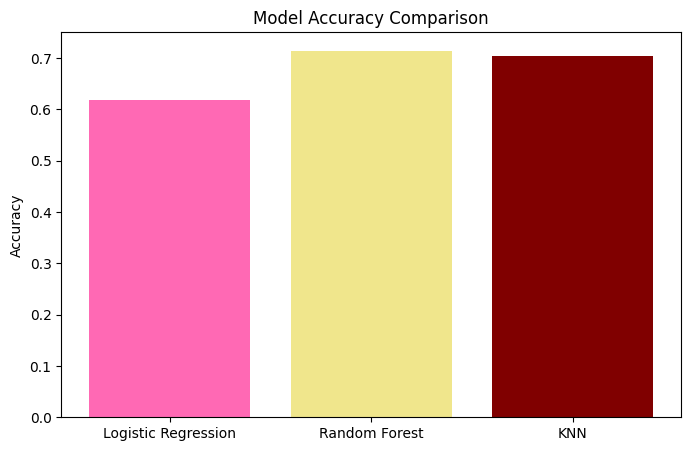

In [243]:
models = ['Logistic Regression', 'Random Forest', 'KNN']
accuracy = [0.6179, 0.7143, 0.7043]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy, color=['hotpink', 'khaki', 'maroon'])

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')

plt.show()

In [242]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "KNN"],
    "Accuracy": [0.6179, 0.7143, 0.7043],
    "Precision": [0.71, 0.68, 0.70],
    "Recall": [0.62, 0.71, 0.70],
    "F1-score": [0.65, 0.68, 0.68]})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.6179,0.71,0.62,0.65
1,Random Forest,0.7143,0.68,0.71,0.68
2,KNN,0.7043,0.70,0.70,0.68
